In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import  tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore')

In [ ]:
df =cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
df

((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [ ]:
(X_train,y_train),(x_test,y_test) = df

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


# **Data Visualization**

In [ ]:
# Define the labels of the dataset

In [ ]:
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid
W_grid = 10
L_grid = 10

In [ ]:
# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

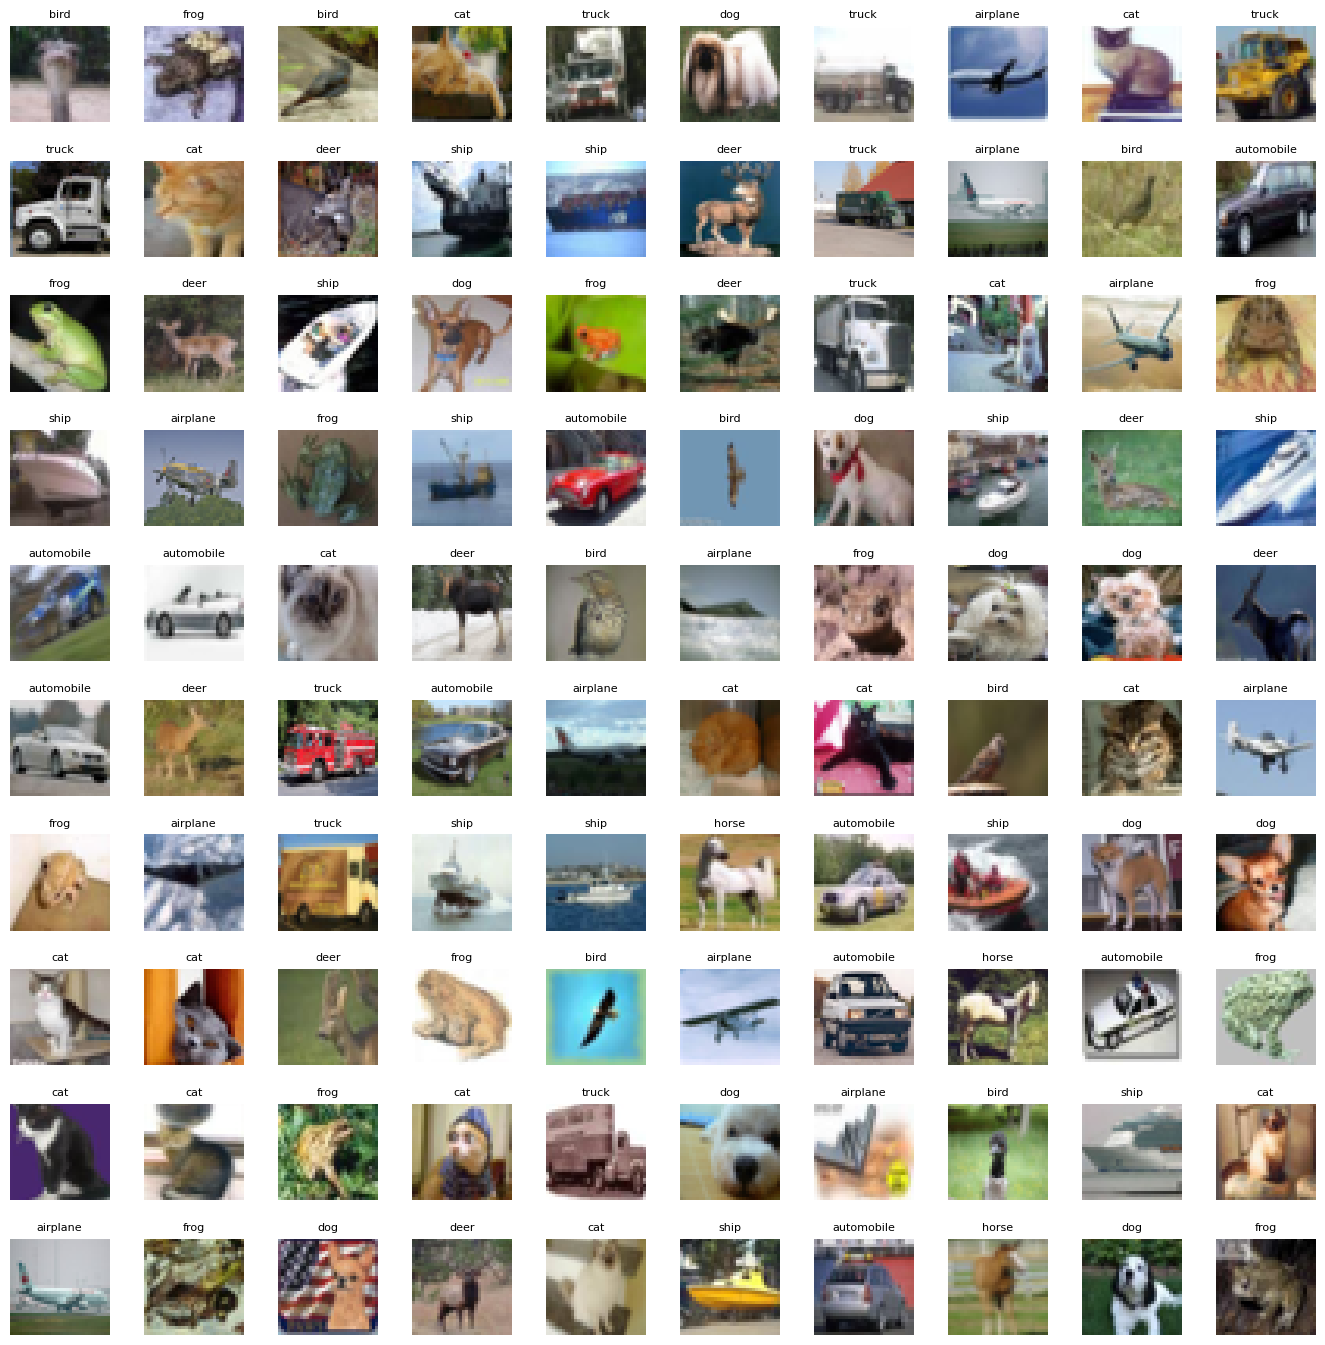

In [ ]:
fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))
axes = axes.ravel() # flaten the 15 x 15 matrix into 225 array

n_train = len(X_train)

# Select a random number from 0 to n_train

for i in np.arange(0,W_grid * L_grid):
  index = np.random.randint(0,n_train)
  axes[i].imshow(X_train[index,1:])
  label_index = int(y_train[index])
  axes[i].set_title(labels[label_index], fontsize = 8)
  axes[i].axis('off')


plt.subplots_adjust(hspace=0.4)


In [ ]:
classes_name = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
classes,counts = np.unique(y_train,return_counts=True)

In [ ]:
classes

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
counts

array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000])

In [ ]:
# Plot of trainning dataset label count

Text(0.5, 1.0, 'Classes Distribution')

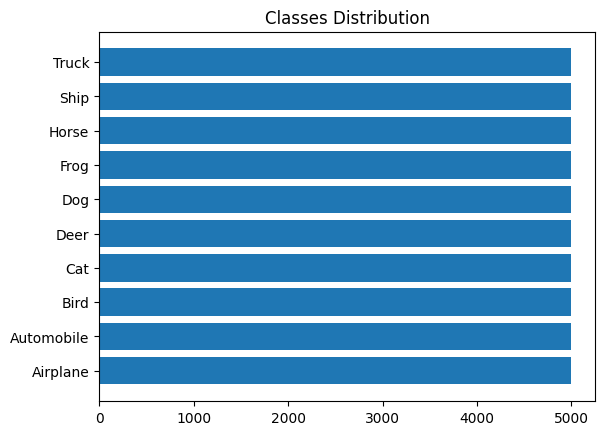

In [ ]:
plt.barh(classes_name,counts)
plt.title('Classes Distribution')

In [ ]:
  # Plot of testing dataset label count

In [ ]:
classes,counts = np.unique(y_test,return_counts=True)

In [ ]:
classes

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
counts

array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000])

Text(0.5, 1.0, 'Classes Distribution')

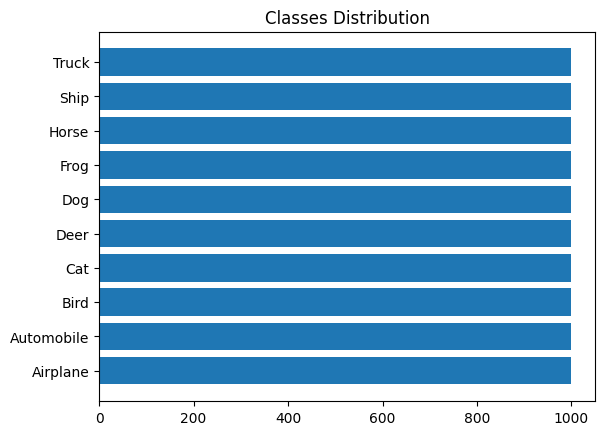

In [ ]:
plt.barh(classes_name,counts)
plt.title('Classes Distribution')


# **Data Preprocessing**

In [ ]:
# Scale the data

In [ ]:
X_train = X_train/255.0
X_test = x_test/255.0

In [ ]:
# Transform target variable into one-hotencoding (tensorflow.keras.utils)

In [ ]:
y_cat_train = to_categorical(y_train)
y_cat_test = to_categorical(y_test)

In [ ]:
y_cat_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
y_cat_train.shape

(50000, 10)

#**Model Building**

In [ ]:
INPUT_SHAPE = (32,32,3)
KERNEL_SIZE = (3,3)

model = Sequential()

# Convolutional Layer
model.add(Conv2D(filters = 32, kernel_size = KERNEL_SIZE,input_shape = INPUT_SHAPE,activation = 'relu',padding = 'same'))
model.add(BatchNormalization())

# Pooling layer
model.add(MaxPool2D(pool_size = (2,2)))

# Dropout layers
model.add(Dropout(0.25))



model.add(Conv2D(filters=64, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=128, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=KERNEL_SIZE, input_shape=INPUT_SHAPE, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))


model.add(Flatten())
# model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

METRICS = ['accuracy',tf.keras.metrics.Precision(name='precision'),tf.keras.metrics.Recall(name='recall')]

model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=METRICS)



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,986 (2.07 MB)

 Trainable params: 542,154 (2.07 MB)

 Non-trainable params: 832 (3.25 KB)

#**Early Stopping**

In [ ]:
early_stop = EarlyStopping(monitor = 'val_loss',patience = 2)

#**Data Augmentation**

In [ ]:
batch_size = 32
data_generator = ImageDataGenerator(width_shift_range = 0.1,height_shift_range = 0.1,horizontal_flip = True)
train_generator = data_generator.flow(X_train,y_cat_train,batch_size)
steps_per_epoch = X_train.shape[0] // batch_size

r = model.fit(train_generator, epochs = 5, validation_data = (x_test,y_cat_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 335s 210ms/step - accuracy: 0.2527 - loss: 2.0947 - precision: 0.4255 - recall: 0.0511 - val_accuracy: 0.2082 - val_loss: 67.0009 - val_precision: 0.2168 - val_recall: 0.2075
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 318s 204ms/step - accuracy: 0.4278 - loss: 1.5790 - precision: 0.6428 - recall: 0.2028 - val_accuracy: 0.2356 - val_loss: 108.4789 - val_precision: 0.2358 - val_recall: 0.2354
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 329s 208ms/step - accuracy: 0.4999 - loss: 1.3943 - precision: 0.6976 - recall: 0.2994 - val_accuracy: 0.3464 - val_loss: 60.0969 - val_precision: 0.3467 - val_recall: 0.3461
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 316s 202ms/step - accuracy: 0.5571 - loss: 1.2595 - precision: 0.7400 - recall: 0.3803 - val_accuracy: 0.2556 - val_loss: 81.8346 - val_precision: 0.2557 - val_recall: 0.2556
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 324s 207ms/step - accuracy: 0.5969 - loss: 1.1609 - precision: 0.7568 - recall: 0.4347 - val_a

#**Model Evaluation**

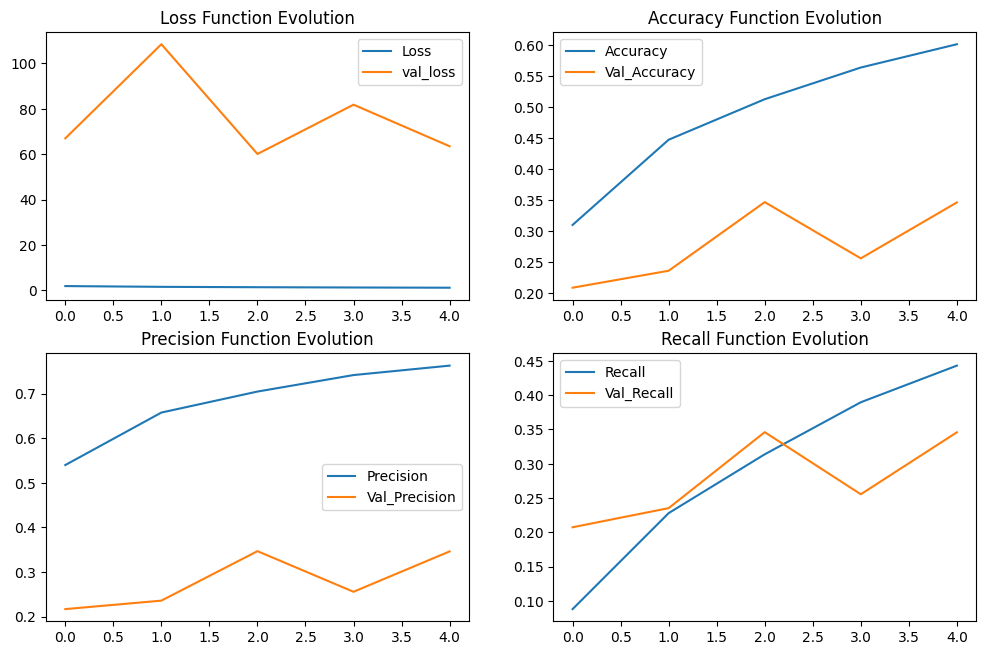

In [36]:
plt.figure(figsize = (12,16))
plt.subplot(4,2,1)
plt.plot(r.history['loss'],label = 'Loss')
plt.plot(r.history['val_loss'],label = 'val_loss')
plt.title('Loss Function Evolution')
plt.legend()

plt.subplot(4,2,2)
plt.plot(r.history['accuracy'],label = 'Accuracy')
plt.plot(r.history['val_accuracy'],label = 'Val_Accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.subplot(4,2,3)
plt.plot(r.history['precision'],label = 'Precision')
plt.plot(r.history['val_precision'],label = 'Val_Precision')
plt.title('Precision Function Evolution')
plt.legend()

plt.subplot(4,2,4)
plt.plot(r.history['recall'],label = 'Recall')
plt.plot(r.history['val_recall'],label = 'Val_Recall')
plt.title('Recall Function Evolution')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.3440 - loss: 62.7935 - precision: 0.3443 - recall: 0.3440
Test Accuracy: 34.59%
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step


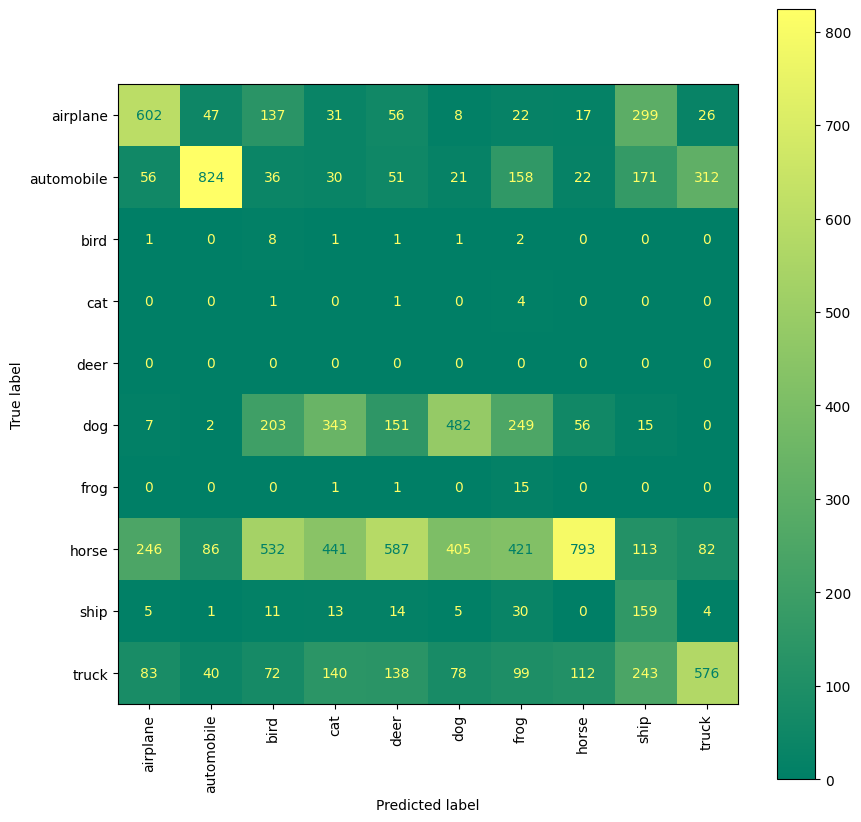

In [37]:
evaluation = model.evaluate(x_test,y_cat_test)
print(f'Test Accuracy: {evaluation[1] * 100:.2f}%')

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis = 1)
cm = confusion_matrix(y_pred,y_test)

display = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = labels)

# NOTE: Fill all variables here with default values of the plot_confusion_matrix
fig,ax = plt.subplots(figsize = (10,10))
display = display.plot(xticks_rotation = 'vertical',ax = ax,cmap = 'summer')

plt.show()

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.48      0.60      0.54      1000
           1       0.49      0.82      0.61      1000
           2       0.57      0.01      0.02      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.32      0.48      0.38      1000
           6       0.88      0.01      0.03      1000
           7       0.21      0.79      0.34      1000
           8       0.66      0.16      0.26      1000
           9       0.36      0.58      0.45      1000

    accuracy                           0.35     10000
   macro avg       0.40      0.35      0.26     10000
weighted avg       0.40      0.35      0.26     10000



#**Test on one image**

Image 100 is [4]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
The model predict that image 100 is 7


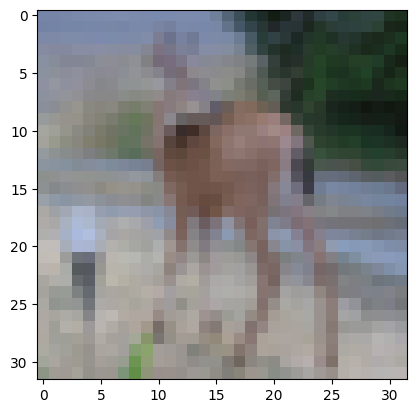

In [39]:
my_image = x_test[100]
plt.imshow(my_image)

# that's a deer image
print(f'Image 100 is {y_test[100]}')

pred_100 = np.argmax(model.predict(my_image.reshape(1,32,32,3)))
print(f'The model predict that image 100 is {pred_100}')

In [42]:
classes_name

['Airplane',
 'Automobile',
 'Bird',
 'Cat',
 'Deer',
 'Dog',
 'Frog',
 'Horse',
 'Ship',
 'Truck']

In [44]:
classes_name[7]

'Horse'

In [45]:
# Let's view more images in a grid format

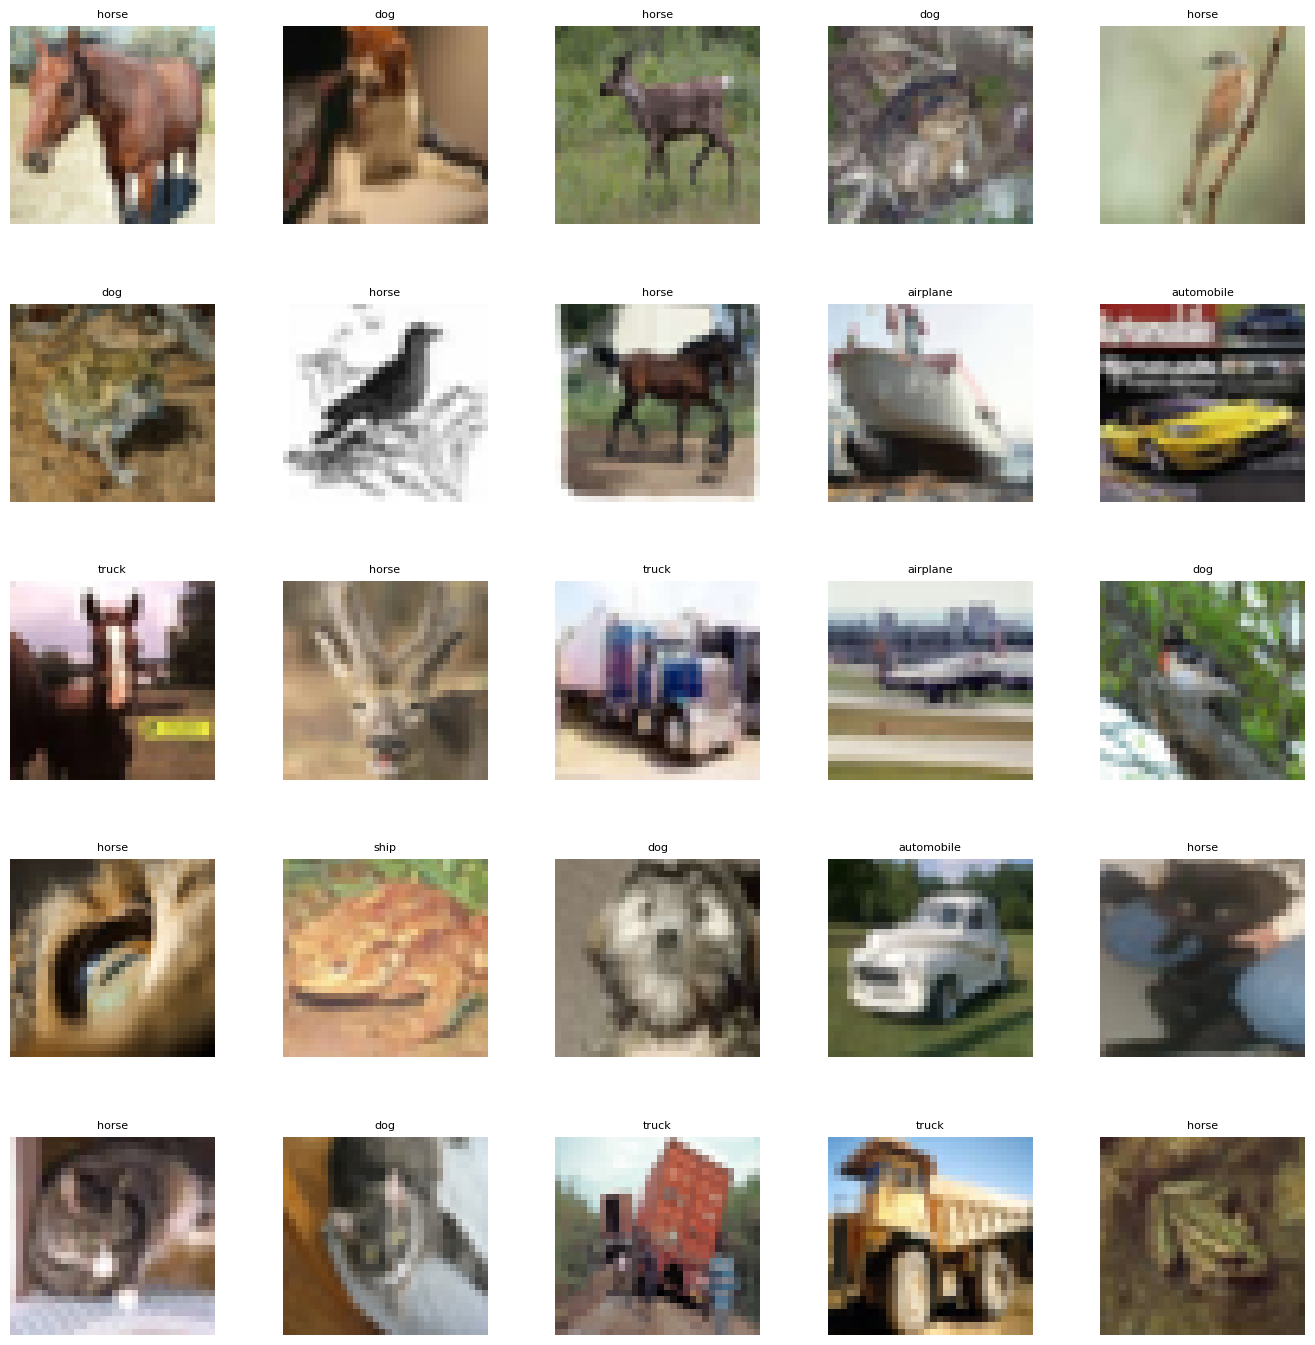

In [54]:
w_grid = 5
l_grid = 5

fig,axes = plt.subplots(w_grid,l_grid,figsize = (17,17))
axes = axes.ravel()

n_test = len(x_test)

for i in np.arange(0,w_grid * l_grid):
  index = np.random.randint(0, n_test)
  axes[i].imshow(x_test[index,1:])
  label_index = int(y_pred[index])
  axes[i].set_title(labels[label_index], fontsize = 8)
  axes[i].axis('off')

plt.subplots_adjust(hspace = 0.4)


In [ ]:
# This function is responsible for displaying an image along with the model's prediction and the true label.

In [67]:
def plot_image(i,predictions_array,true_label,img):
  predictions_array,true_label, img = predictions_array,true_label[i],img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap = plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel(f"{labels[int(predicted_label)]} {100*np.max(predictions_array):2.0f}% ({labels[int(true_label)]})",color = color)

In [68]:
# This function displays a bar chart showing the model's predicted probabilities for each class.

In [69]:
def plot_value_array(i,predictions_array,true_label):
  predictions_array,true_label = predictions_array,int(true_label[i])
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])

  thisplot = plt.bar(range(10),predictions_array,color = "#777777")

  plt.ylim([0,1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step


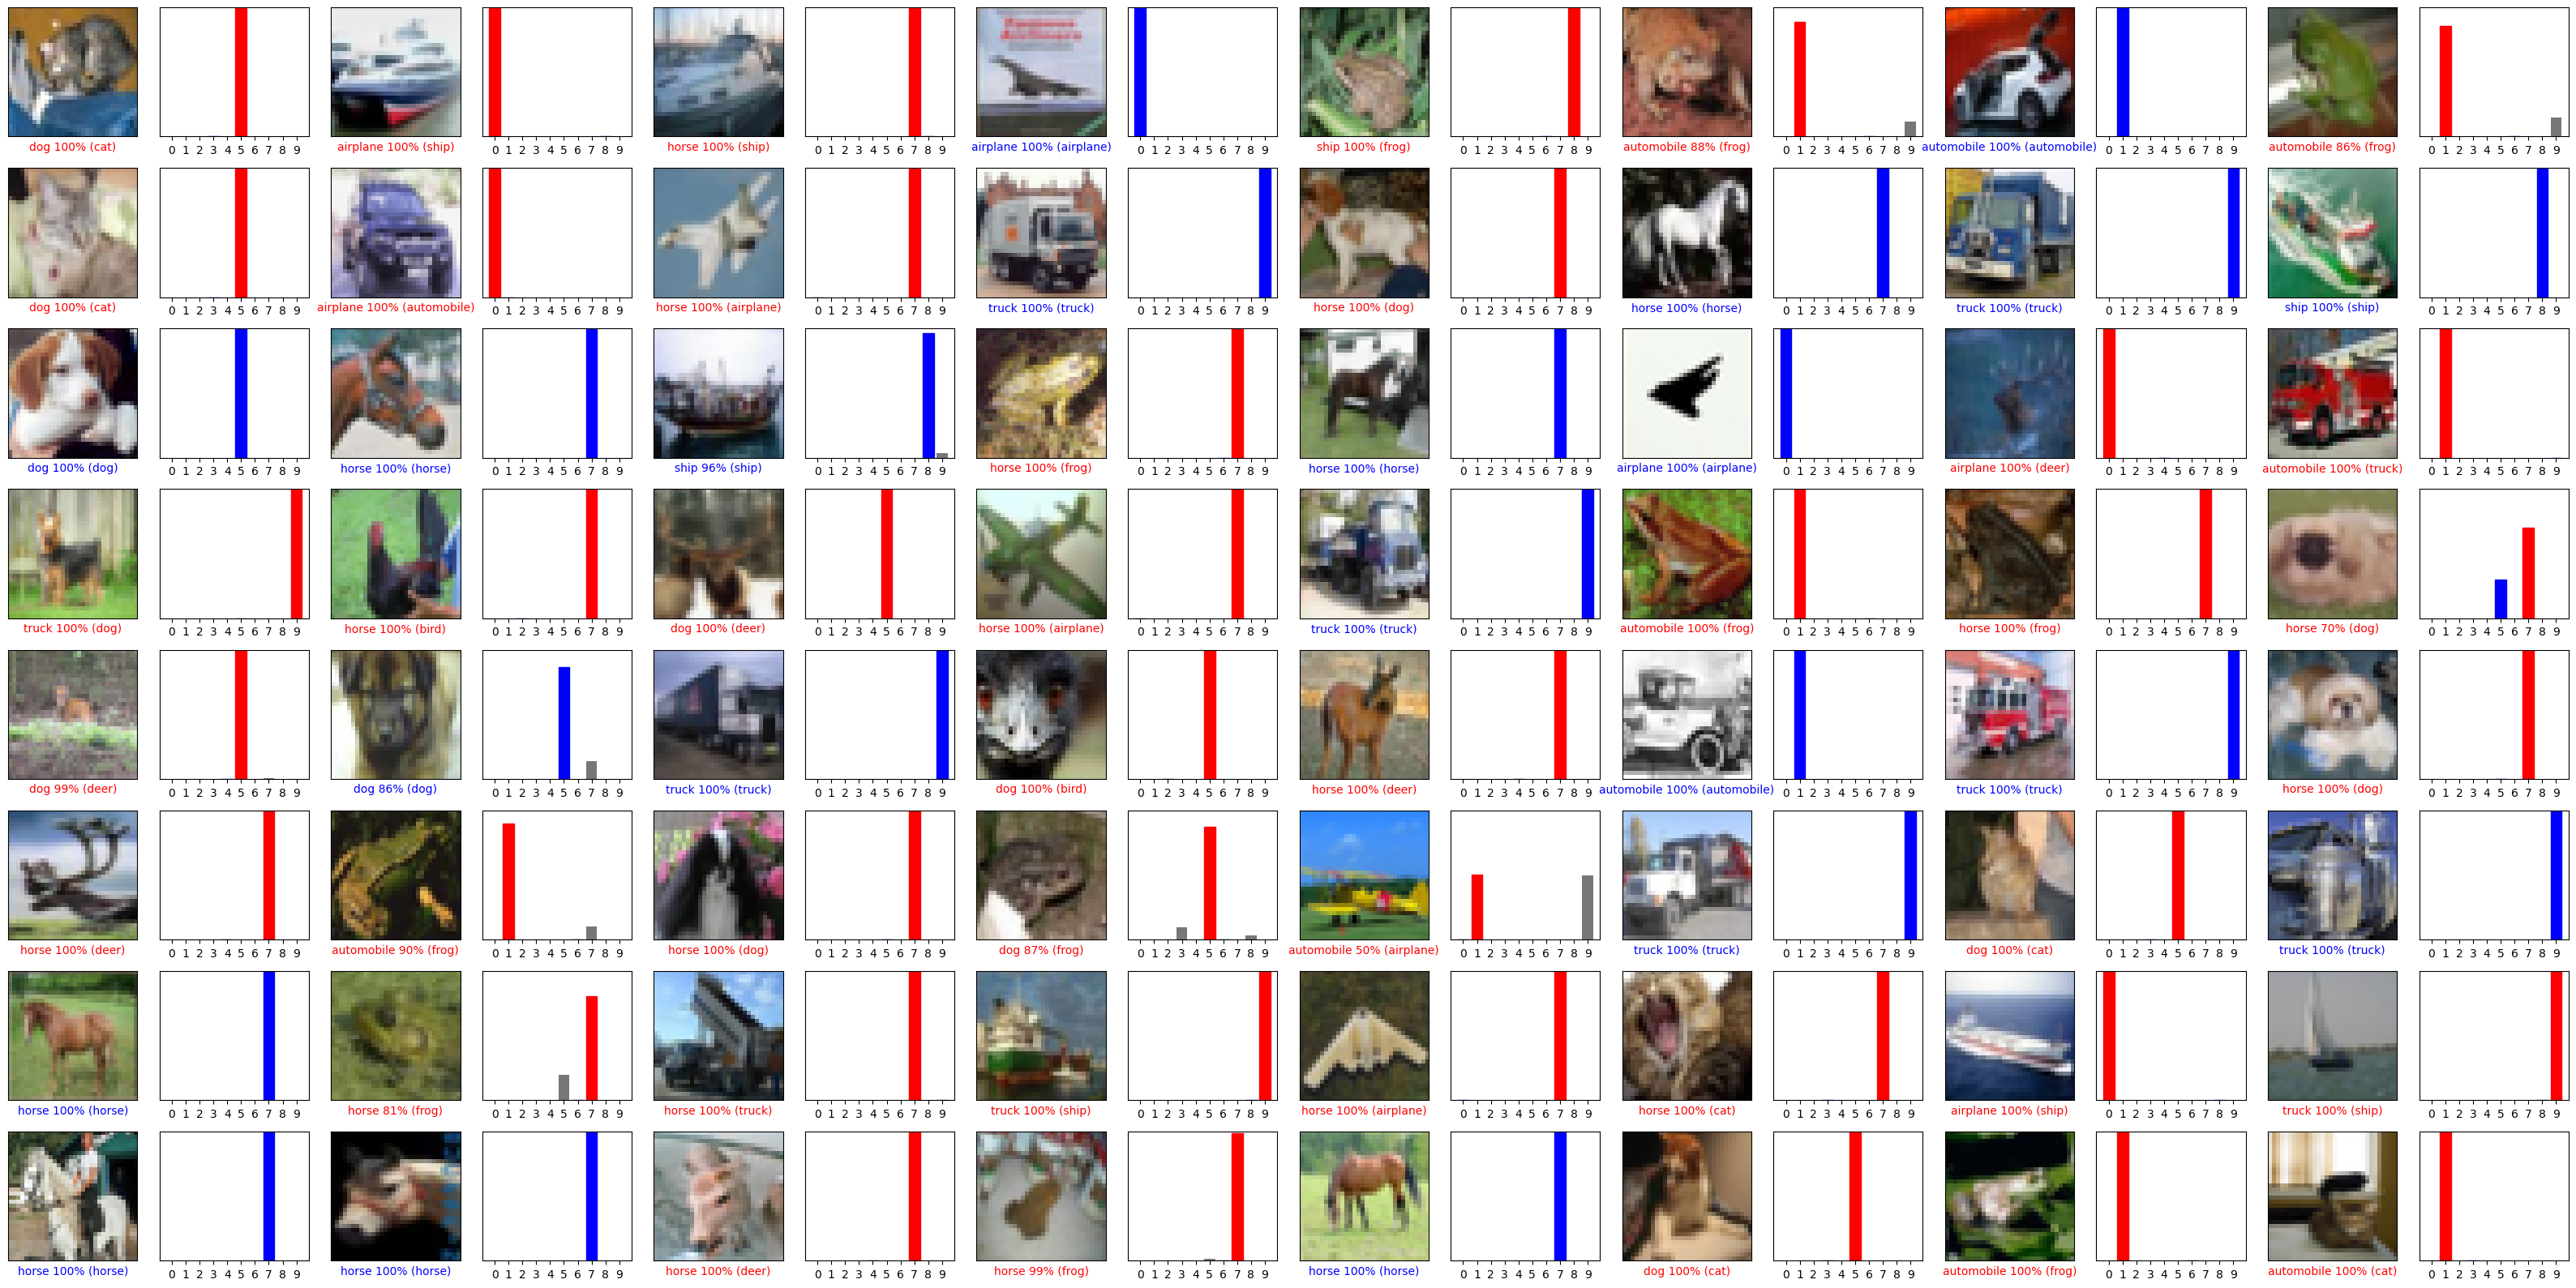

In [70]:
predictions = model.predict(x_test)

# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.

num_rows = 8
num_cols = 8
num_images = num_rows * num_cols

plt.figure(figsize = (2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
  plt.subplot(num_rows,2 * num_cols, 2 * i + 1)
  plot_image(i,predictions[i],y_test,x_test)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], y_test)

plt.tight_layout()
plt.show()